# Absolute free energy of an isolated butane molecule

This notebook demonstrates the complete FEcrys workflow for a single molecule:

1. load a molecular trajectory and its potential energies;
2. express coordinates in nanometres and energies in units of $k_\mathrm{B}T$;
3. define a callable potential-energy surface using MACE-OFF;
4. construct and validate the isolated-molecule internal-coordinate map;
5. build and train a `PGMmol` normalising flow; and
6. estimate the absolute free energy by selective evaluation and BAR reweighting.

The notebook uses butane at 300 K as the worked example. Expensive operations—MACE evaluation, training, and reweighting—are clearly identified so that cached results can be reused.

## 1. Imports and runtime configuration

TensorFlow's memory-growth setting must be defined before importing FEcrys, because FEcrys imports TensorFlow internally. Imports are explicit so that the notebook also records which public components the workflow depends on.

In [1]:
import os

os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ase import Atoms
from ase.io import read
from IPython.display import display
from mace.calculators import mace_off
from rdkit.Chem import Draw
from scipy.stats import gaussian_kde
from tqdm.auto import tqdm

from O.interface import NN_interface_sc_multimap_selective_evaluation_
from O.NN.pgm import PGMmol
from O.NN.representation_layers import SingleMolecule_map
from O.util_np import load_pickle_

/Users/matteo/miniforge3/envs/FEcrys_metal/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



## 2. Experiment settings and file locations

All tunable values are collected here. Paths are relative to the repository, so the notebook can be moved or cloned without editing a user-specific absolute path.

- `START_FRAME` can discard equilibration frames.
- `FRACTION_TRAINING` controls the training/validation split.
- `N_ENERGY_CHECKS` limits the number of expensive MACE evaluations used for the consistency check.
- Results are written below `butane/results/`.

In [2]:
NAME = "butane"
MODEL_NAME = "butane_maceoff_medium"
TEMPERATURE_K = 300.0
START_FRAME = 0
FRACTION_TRAINING = 0.5
N_ENERGY_CHECKS = 50

N_LAYERS = 2
LEARNING_RATE = 5e-4
N_TRAINING_BATCHES = 80
BATCHES_BETWEEN_EVALUATIONS = 4
N_SELECTIVE_EVALUATIONS = 12

DATA_DIR = Path(NAME)
TRAJECTORY_FILE = DATA_DIR / "restrained_100ps.traj"
PDB_FILE = DATA_DIR / "seed_anti.pdb"
ENERGY_FILE = DATA_DIR / "maceoff_medium_float64_energies.dat"
RESULTS_DIR = DATA_DIR / "results"

for required_file in (TRAJECTORY_FILE, PDB_FILE):
    if not required_file.exists():
        raise FileNotFoundError(required_file)

print("Trajectory:", TRAJECTORY_FILE)
print("Topology:  ", PDB_FILE)
print("Results:   ", RESULTS_DIR)

Trajectory: butane/restrained_100ps.traj
Topology:   butane/seed_anti.pdb
Results:    butane/results


## 3. Load the trajectory and reference energies

ASE reads the stored trajectory. The MACE-OFF medium model supplies the same potential used both for the reference trajectory energies and for later evaluation of generated structures.

If the energy file already exists, it is loaded immediately. Otherwise this cell evaluates every trajectory frame and caches the energies in electronvolts. The first uncached execution can therefore be slow.

In [3]:
atoms_traj = read(TRAJECTORY_FILE, index=":")
calculator = mace_off(
    model="medium",
    device="cpu",  # use "mps" on Apple Silicon if supported by the installation
    default_dtype="float64",
)

if ENERGY_FILE.exists():
    print(f"Loading cached energies from {ENERGY_FILE}")
    potential_energy_eV = np.loadtxt(ENERGY_FILE)
else:
    print("No cached energy file found; evaluating the trajectory with MACE-OFF.")
    potential_energy_eV = []
    for atoms in tqdm(atoms_traj, desc="MACE energies"):
        atoms.calc = calculator
        potential_energy_eV.append(atoms.get_potential_energy())

    potential_energy_eV = np.asarray(potential_energy_eV, dtype=np.float64)
    np.savetxt(
        ENERGY_FILE,
        potential_energy_eV,
        header="Potential energy / eV",
    )
    print(f"Saved energies to {ENERGY_FILE}")

potential_energy_eV = np.asarray(potential_energy_eV, dtype=np.float64).reshape(-1)
if len(potential_energy_eV) != len(atoms_traj):
    raise ValueError(
        f"Trajectory contains {len(atoms_traj)} frames but the energy file "
        f"contains {len(potential_energy_eV)} values."
    )

print(f"Frames:      {len(atoms_traj)}")
print(f"Mean energy: {potential_energy_eV.mean():.8f} eV")
print(f"Std energy:  {potential_energy_eV.std():.8f} eV")

Using MACE-OFF23 MODEL for MACECalculator with /Users/matteo/.cache/mace/MACE-OFF23_medium.model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Loading cached energies from butane/maceoff_medium_float64_energies.dat
Frames:      1001
Mean energy: -4313.86374876 eV
Std energy:  0.13890106 eV


/Users/matteo/miniforge3/envs/FEcrys_metal/lib/python3.12/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


## 4. Prepare FEcrys coordinates, reduced energies, and the potential function

FEcrys expects Cartesian coordinates and box vectors in nanometres, whereas ASE stores them in ångström. FEcrys also works with reduced energies $u = U/(k_\mathrm{B}T)$, so the MACE energies are converted from electronvolts to dimensionless $k_\mathrm{B}T$ units.

The function `u_calc` is the bridge back to the physical potential. It accepts a batch of FEcrys coordinates in nanometres and returns one reduced energy per structure with shape `(n_frames, 1)`.

In [4]:
trajectory = atoms_traj[START_FRAME:]
energy_eV = potential_energy_eV[START_FRAME:]

# Boltzmann constant in eV K^-1.
K_B_EV_PER_K = 8.617333262145e-5
eV_to_kT = 1.0 / (K_B_EV_PER_K * TEMPERATURE_K)

r = np.asarray(
    [atoms.get_positions() for atoms in trajectory],
    dtype=np.float32,
) / 10.0
b0 = np.asarray(trajectory[0].get_cell().array, dtype=np.float32) / 10.0
u = (energy_eV * eV_to_kT).reshape(-1, 1)
chemical_symbols = trajectory[0].get_chemical_symbols()

def u_calc(coordinates_nm):
    """Evaluate MACE reduced energies for coordinates in nanometres.

    Parameters
    ----------
    coordinates_nm : array_like
        Cartesian coordinates shaped (frames, atoms, 3) in nm.

    Returns
    -------
    numpy.ndarray
        Reduced potential energies shaped (frames, 1) in kT.
    """
    coordinates_nm = np.asarray(coordinates_nm)
    energies_kT = []
    for positions_nm in coordinates_nm:
        atoms = Atoms(
            chemical_symbols,
            positions=positions_nm * 10.0,
            pbc=False,
        )
        atoms.calc = calculator
        energies_kT.append(atoms.get_potential_energy() * eV_to_kT)
    return np.asarray(energies_kT, dtype=np.float64).reshape(-1, 1)

print("r:", r.shape, "nm")
print("b0:", b0.shape, "nm")
print("u:", u.shape, "kT")
print("energy range:", float(u.min()), "to", float(u.max()), "kT")

r: (1001, 14, 3) nm
b0: (3, 3) nm
u: (1001, 1) kT
energy range: -166880.2381008228 to -166847.22692627722 kT


## 5. Verify the stored and callable potentials

Training uses the stored trajectory energies, while reweighting evaluates `u_calc` on newly generated structures. They must represent the same potential, temperature, units, and atom ordering.

This diagnostic recomputes a small, evenly spaced subset. Points should lie on the diagonal and the energy differences should be close to numerical precision. A systematic offset or slope indicates a unit, calculator, or configuration mismatch and should be resolved before continuing.

u_calc(r) - stored u / kT
mean: -4.474290180951357e-06
std:  1.936942419946432e-05
MAE:  1.6291206702589988e-05
RMSE: 1.9879483555720246e-05


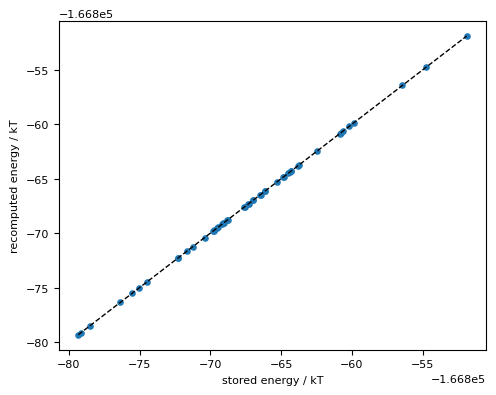

In [5]:
n_check = min(N_ENERGY_CHECKS, len(r))
check_indices = np.linspace(0, len(r) - 1, n_check, dtype=int)

u_stored = u[check_indices]
u_recalculated = u_calc(r[check_indices])
energy_difference = u_recalculated - u_stored

print("u_calc(r) - stored u / kT")
print("mean:", float(energy_difference.mean()))
print("std: ", float(energy_difference.std()))
print("MAE: ", float(np.mean(np.abs(energy_difference))))
print("RMSE:", float(np.sqrt(np.mean(energy_difference**2))))

limits = [
    min(float(u_stored.min()), float(u_recalculated.min())),
    max(float(u_stored.max()), float(u_recalculated.max())),
]
plt.figure(figsize=(5, 4))
plt.scatter(u_stored, u_recalculated, s=14)
plt.plot(limits, limits, "k--", linewidth=1)
plt.xlabel("stored energy / kT")
plt.ylabel("recomputed energy / kT")
plt.tight_layout()
plt.show()

## 6. Construct the single-state FEcrys interface

The interface keeps the trajectory, stored energies, callable potential, coordinate map, model, trainer, and free-energy analysis in one workflow object.

For an isolated molecule:

- `PGMmol` is the conformation-only normalising-flow model;
- `SingleMolecule_map` removes physically irrelevant global translation and rotation; and
- one state is used because this example describes one butane ensemble.

In [6]:
nn = NN_interface_sc_multimap_selective_evaluation_(
    name=MODEL_NAME,
    n_states=1,
    list_r=[r],
    list_b0=[b0],
    list_u=[u],
    list_u_=[u_calc],
    single_mol_pdb_file=str(PDB_FILE),
    training=True,
    fraction_training=FRACTION_TRAINING,
    running_in_notebook=True,
    model_class=PGMmol,
    ic_map_class=SingleMolecule_map,
)

state = nn.nns[0]
print("coordinates:", state.r.shape)
print("energies:   ", state.u.shape)
print("potential callable:", callable(state.u_))

coordinates: (1001, 14, 3)
energies:    (1001, 1)
potential callable: True


## 7. Choose and inspect the internal-coordinate tree

The internal-coordinate map represents the molecule using bond lengths, angles, and torsions. `ind_root_atom=1` selects the central atom used to construct the Cartesian anchor block; this choice should remain fixed for a given topology so trained models remain compatible.

The displayed RDKit diagram uses atom-map numbers matching the indices in the coordinate tree. If a different molecule is introduced, inspect this diagram and choose a chemically sensible root before proceeding.

molecule with 14 atoms, of which 4 are heavy atoms, and the rest are 10 hydrogens.
atoms with incides [1, 8, 0] are set to be the Cartesian_Block
position of the molecule specified by atoms with index: 1
rotation of the molecule specified by atoms with indices: [8, 0]
conformation of the molecule specified by all other atoms.
Internal-coordinate tree (A, B, C, D references):
{0: [8], 1: [1, 8], 2: [0, 1, 8], 3: [4, 0, 1, 8], 4: [5, 0, 1, 8], 5: [6, 0, 1, 8], 6: [2, 1, 0, 4], 7: [3, 2, 1, 8], 8: [11, 3, 2, 1], 9: [12, 3, 2, 1], 10: [13, 3, 2, 1], 11: [9, 2, 1, 8], 12: [10, 2, 1, 8], 13: [7, 1, 0, 4]}


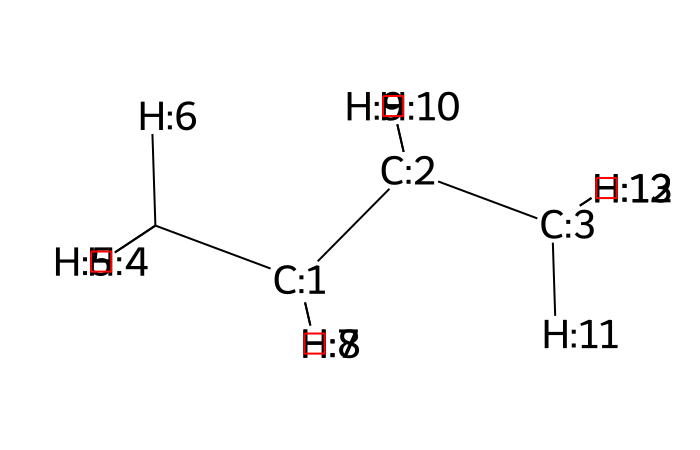

In [7]:
nn.set_ic_map_step1(ind_root_atom=1, option=None)

coordinate_map = state.ic_map
print("Internal-coordinate tree (A, B, C, D references):")
print(np.asarray(coordinate_map.ABCD))

display(Draw.MolToImage(coordinate_map.mol, size=(700, 450)))

## 8. Fit and validate the coordinate representation

The preprocessing is deliberately split into two operations:

1. `set_ic_map_step2` removes global translation, creates the training/validation split, and verifies that the callable potential matches the stored dataset.
2. `set_ic_map_step3` fits the marginal coordinate scalings and tests numerical inversion.

For a single isolated molecule there is one molecule per unit cell. Inspect the reported inverse errors before constructing the trainable model.

In [8]:
nn.set_ic_map_step2(check_PES=True)
nn.set_ic_map_step3(n_mol_unitcells=1)

state = nn.nns[0]
print("training coordinates:  ", state.r_training.shape)
print("validation coordinates:", state.r_validation.shape)

COM removed from data without taking into account PBC of the box
inds_rand attempt: 1
! not found
inds_rand attempt: 2
! not found
inds_rand attempt: 3
found !
checking that PES matches the sampled dataset:
errT: 6.100119790062308e-07 -7.772661047056317e-05 8.271849947050214e-05
errV: 8.651128126133583e-08 -8.037351653911173e-05 8.002185495570302e-05


I0000 00:00:1783875989.512807 5990852 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1783875989.512992 5990852 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


initialising on 1001 datapoints provided
8 out of 11 potentially periodic marginal variables are set to periodic
This topology is shared over all molecules.

ic_map inversion errors on a small random batch:
positons: 0.6360202
volume: 1.5258789e-05
1.0000008
training coordinates:   (500, 14, 3)
validation coordinates: (501, 14, 3)


## 9. Configure output directories and safe batch sizes

Result paths are assigned to both the multistate wrapper and its single-state interface because both objects participate in persistence. Batch sizes are capped by the available training and validation data, preventing accidental requests for batches larger than the dataset.

In [9]:
result_directories = {
    "dir_results_BAR": RESULTS_DIR / "training_results" / "BAR",
    "dir_results_misc": RESULTS_DIR / "training_results" / "misc",
    "dir_results_samples": RESULTS_DIR / "training_results" / "samples",
    "dir_results_models": RESULTS_DIR / "training_results" / "fitted_models",
}

for interface in [nn, *nn.nns]:
    for attribute, directory in result_directories.items():
        directory.mkdir(parents=True, exist_ok=True)
        setattr(interface, attribute, str(directory) + os.sep)

min_training_frames = min(len(item.r_training) for item in nn.nns)
min_validation_frames = min(len(item.r_validation) for item in nn.nns)
training_batch_size = min(1000, min_training_frames)
evaluation_batch_size = min(800, min_training_frames, min_validation_frames)

print("training batch size:  ", training_batch_size)
print("evaluation batch size:", evaluation_batch_size)
print("model save prefix:    ", nn.name_save_model)

training batch size:   500
evaluation batch size: 500
model save prefix:     butane/results/training_results/fitted_models/butane_maceoff_medium_SC__model_


## 10. Build the normalising flow and trainer

`PGMmol` applies alternating rational-quadratic spline coupling layers to the molecular internal coordinates. Two layers keep this example modest.

`identity_init=True` starts the spline transformations at the identity: before learning, latent coordinates remain close to the representation coordinates and the coupling log-Jacobian is close to zero. This provides a stable, interpretable starting point without changing the coordinate representation itself.

In [10]:
nn.set_model(
    n_layers=N_LAYERS,
    learning_rate=LEARNING_RATE,
    evaluation_batch_size=evaluation_batch_size,
    identity_init=True,
)
nn.set_trainer(
    n_batches_between_evaluations=BATCHES_BETWEEN_EVALUATIONS,
)

There are 1074060 trainable parameters in this model, among 32 trainable weights.
[To see dimensionalities of the trainable weights print(list(self.shapes_trainable_weights)).] 


<unknown>:732: SyntaxWarning: invalid escape sequence '\p'
<unknown>:732: SyntaxWarning: invalid escape sequence '\p'


inv_test_res0 ([[np.float32(0.12949817), np.float32(0.6360202)], [np.float32(0.0), np.float32(0.0), np.float32(0.0)]], [[[np.float32(4.4140324e-07), np.float32(4.7683716e-06)]], [np.float32(-1.2207032e-07), np.float32(-7.6293945e-06), np.float32(7.6293945e-06)]])


'0.45 79 79 19 AVMD_T:[-166733.55666435] AVMD_V:[np.float64(-166748.66327833457)] || FE:[np.float64(0.0)] SD:[np.float64(0.0)]'

## 11. Train and save the model

Training maximises the likelihood of the molecular trajectory under the flow. At each evaluation interval, FEcrys records validation diagnostics and structures for later selective reweighting.

This is a computationally expensive step. The native FEcrys model artifact is attempted first. If full serialisation fails, the fallback preserves all trainable arrays and a small JSON manifest; that fallback is a recovery artifact rather than a directly loadable FEcrys model.

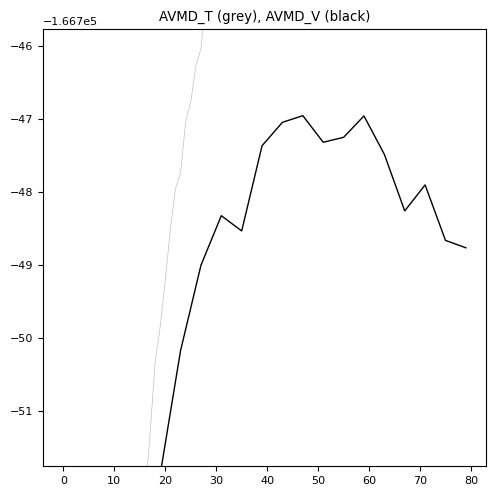

training time so far: 0.45 minutes
saved butane/results/training_results/misc/butane_maceoff_medium_SC__misc_
misc training outputs were saved
saved butane/results/training_results/fitted_models/butane_maceoff_medium_SC__model_
Saved FEcrys model: butane/results/training_results/fitted_models/butane_maceoff_medium_SC__model_


In [11]:
nn.train(
    n_batches=N_TRAINING_BATCHES,
    training_batch_size=training_batch_size,
    f_halfwindow_visualisation=[3, 1.0],
)

try:
    nn.save_model_()
    print("Saved FEcrys model:", nn.name_save_model)
except Exception as error:
    print("Full model serialisation failed:", repr(error))
    fallback_directory = Path(nn.dir_results_models)
    fallback_directory.mkdir(parents=True, exist_ok=True)

    weights = list(nn.model.trainable_weights)
    weights_file = fallback_directory / f"{nn.name}_weights.npz"
    metadata_file = fallback_directory / f"{nn.name}_weights.json"

    np.savez_compressed(
        weights_file,
        **{f"array_{index}": weight.numpy() for index, weight in enumerate(weights)},
    )
    metadata_file.write_text(
        json.dumps(
            {
                "model_name": nn.name,
                "number_of_states": nn.n_crystals,
                "number_of_weight_arrays": len(weights),
                "weight_shapes": [list(weight.shape) for weight in weights],
            },
            indent=2,
        ),
        encoding="utf-8",
    )
    print("Saved fallback weights:", weights_file)
    print("Saved fallback metadata:", metadata_file)

## 12. Select evaluations and perform BAR reweighting

The validation diagnostic `AVMD_V` ranks saved training evaluations. Selective evaluation concentrates expensive potential calls on the most promising saved model states rather than recomputing every checkpoint.

BAR then combines samples from the learned distribution and the physical potential to estimate the absolute free energy. The reported uncertainty is the BAR standard error in $k_\mathrm{B}T$. If this section is run in a fresh kernel after training, `load_misc_` restores the saved diagnostics.

Best saved evaluations:
estimate= 11 batch=    47 AVMD_V=-166746.950791
estimate= 14 batch=    59 AVMD_V=-166746.954289
estimate= 10 batch=    43 AVMD_V=-166747.041797
estimate= 13 batch=    55 AVMD_V=-166747.248139
estimate= 12 batch=    51 AVMD_V=-166747.315682
estimate=  9 batch=    39 AVMD_V=-166747.363286
estimate= 15 batch=    63 AVMD_V=-166747.481975
estimate= 17 batch=    71 AVMD_V=-166747.901530
estimate= 16 batch=    67 AVMD_V=-166748.258384
estimate=  7 batch=    31 AVMD_V=-166748.324073

two-state BAR evaluation in macrostate 0:
evaluation batch 11: evaluating potential energies on model samples. The estimate will be saved.


******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************



evaluation batch 14: evaluating potential energies on model samples. The estimate will be saved.
evaluation batch 10: evaluating potential energies on model samples. The estimate will be saved.
evaluation batch 13: evaluating potential energies on model samples. The estimate will be saved.
evaluation batch 12: evaluating potential energies on model samples. The estimate will be saved.
evaluation batch 9: evaluating potential energies on model samples. The estimate will be saved.
evaluation batch 15: evaluating potential energies on model samples. The estimate will be saved.
evaluation batch 17: evaluating potential energies on model samples. The estimate will be saved.
evaluation batch 16: evaluating potential energies on model samples. The estimate will be saved.
evaluation batch 7: evaluating potential energies on model samples. The estimate will be saved.
evaluation batch 8: evaluating potential energies on model samples. The estimate will be saved.
evaluation batch 18: evaluating p

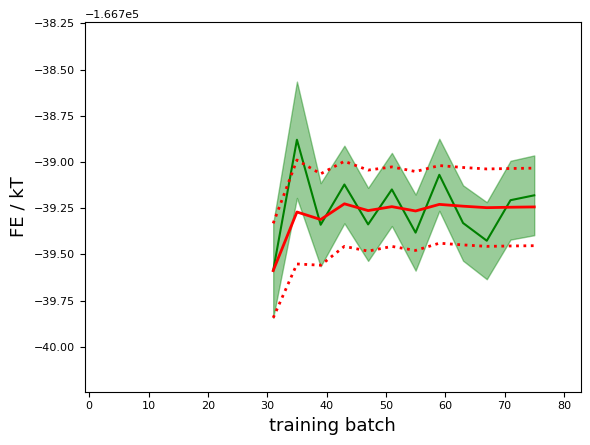

In [12]:
state = nn.nns[0]
if not hasattr(state, "estimates"):
    nn.load_misc_()

avmd_validation = np.asarray(state.estimates[0, :, 1], dtype=float)
valid = np.isfinite(avmd_validation) & (avmd_validation > -1e19)
valid_indices = np.flatnonzero(valid)
if len(valid_indices) == 0:
    raise RuntimeError("No valid AVMD_V evaluations are available for reweighting.")

ranked_indices = valid_indices[np.argsort(avmd_validation[valid])[::-1]]
print("Best saved evaluations:")
for index in ranked_indices[:10]:
    print(
        f"estimate={index:3d}",
        f"batch={state.evaluation_grid[index]:6d}",
        f"AVMD_V={avmd_validation[index]:.6f}",
    )

nn.solve_BAR_using_pymbar_(
    rerun=True,
    n_selective_evalautions=N_SELECTIVE_EVALUATIONS,
)

print("Absolute free energy / kT:", state.BAR_V_FE)
print("BAR standard error / kT:  ", state.BAR_V_SE)

nn.plot_result_(crystal_index=0, window=1, n_mol=1)

## 13. Optional diagnostic: compare MD and generated energy distributions

A useful qualitative test is to compare physical energies from the molecular-dynamics data with energies of structures generated early and at the best saved evaluation.

Improved overlap is expected as training progresses. Very high generated energies indicate poorly sampled or unphysical structures; they are excluded from this visualisation using a percentile window, but they must not be silently removed from the actual BAR calculation.

In [ ]:
MAX_SAMPLES_PER_EVALUATION = None
PLOT_PERCENTILES = (0.5, 80.0)
N_HISTOGRAM_BINS = 80

first_index = valid_indices[0]
best_index = ranked_indices[0]

def generated_energies(estimate_index, max_samples=None):
    """Load one saved evaluation and compute physical energies of its samples."""
    prefix = (
        state.name_save_BAR_inputs
        + "_BAR_input_"
        + str(estimate_index)
        + "_state0_"
    )
    sample_file = prefix + "_r_&_ln(q(r))"
    generated_r, _, validation_u, _, _ = load_pickle_(sample_file)

    if max_samples is not None:
        generated_r = generated_r[:max_samples]
        validation_u = validation_u[:max_samples]

    return state.u_(generated_r).reshape(-1), np.asarray(validation_u).reshape(-1)

u_generated_first, _ = generated_energies(
    first_index,
    max_samples=MAX_SAMPLES_PER_EVALUATION,
)
u_generated_best, _ = generated_energies(
    best_index,
    max_samples=MAX_SAMPLES_PER_EVALUATION,
)
u_md = np.asarray(state.u).reshape(-1)

energy_reference = float(u_md.mean())
distributions = {
    "MD trajectory": u_md - energy_reference,
    f"generated at batch {state.evaluation_grid[first_index]}": (
        u_generated_first - energy_reference
    ),
    f"generated at batch {state.evaluation_grid[best_index]}": (
        u_generated_best - energy_reference
    ),
}

combined = np.concatenate(list(distributions.values()))
lower, upper = np.percentile(combined, PLOT_PERCENTILES)
padding = 0.1 * (upper - lower)
plot_range = (lower - padding, upper + padding)
x_grid = np.linspace(*plot_range, 500)

plt.figure(figsize=(9, 4.5))
line_styles = ["-", "--", ":"]
for (label, values), line_style in zip(distributions.items(), line_styles):
    in_range = values[(values >= plot_range[0]) & (values <= plot_range[1])]
    plt.hist(
        in_range,
        bins=N_HISTOGRAM_BINS,
        range=plot_range,
        density=True,
        histtype="step",
        linewidth=1.5,
        alpha=0.7,
    )
    if len(in_range) > 1 and np.std(in_range) > 0:
        density = gaussian_kde(in_range)
        plt.plot(
            x_grid,
            density(x_grid),
            linestyle=line_style,
            linewidth=2,
            label=label,
        )

plt.xlabel("energy - MD mean / kT")
plt.ylabel("density")
plt.yscale("log")
plt.ylim(bottom=1e-4)
plt.ylim(top=1e0)
plt.title("Physical-energy overlap during flow training")
plt.legend()
plt.tight_layout()
plt.show()

for label, values in distributions.items():
    print(
        f"{label:32s}",
        f"mean={values.mean(): .5f}",
        f"std={values.std(ddof=1): .5f}",
        f"min={values.min(): .5f}",
        f"max={values.max(): .5f}",
    )